In [4]:
import pandas as pd

TARGET = "orgc" # target variable to predict orgc or tceq = 'orgc'
file_path = f"D:/tierra/datasets/Mexico_standardized_cfvo_{TARGET}.csv"

pd.set_option('display.max_columns', None)  # Show all columns in the output
df = pd.read_csv(file_path)

landcover_mapping = {
    1: "Evergreen Needleleaf Forests",
    2: "Evergreen Broadleaf Forests", 
    3: "Deciduous Needleleaf Forests",
    4: "Deciduous Broadleaf Forests",
    5: "Mixed Forests",
    6: "Closed Shrublands",
    7: "Open Shrublands",
    8: "Woody Savannas", 
    9: "Savannas",
    10: "Grasslands",
    11: "Permanent Wetlands",
    12: "Croplands",
    13: "Urban and Built-up Lands",
    14: "Cropland/Natural Vegetation Mosaics",
    15: "Permanent Snow and Ice",
    16: "Barren",
    17: "Water Bodies",
    255: "Unclassified"
}

# Map landcover codes to names
df['landcover'] = df['landcover'].map(landcover_mapping)

bedrock_mapping = {
    "rocas_metamorficas": "Metamorphic rocks",
    "rocas_igneas": "Igneous rocks",
    "rocas_sedimentarias": "Sedimentary rocks"
}

# Map bedrock types to names
df['bedrock'] = df['bedrock'].map(bedrock_mapping)

ecoregion_mapping = {
    "Tropical húmeda": "Tropical humid",
    "Inundable o Transición tierra-mar": "Inundated or land-sea transition",
    "Templada subhúmeda": "Temperate subhumid",
    "Tropical subhúmeda": "Tropical subhumid",
    "Árida y semiárida": "Arid or Semi-arid",
    "Templada húmeda": "Temperate humid",
    "Cuerpo de Agua": "Water body"
}

# Map ecoregion types to names
df['zone_name'] = df['zone_name'].map(ecoregion_mapping)

soil_type_mapping = {
    "FLUVISOL EUTRICO": "Acrisols",
    "REGOSOL EUTRICO": "Andosols",
    "CAMBISOL EUTRICO": "Arenosols",
    "CAMBISOL CROMICO": "Cambisols",
    "REGOSOL DISTRICO": "Kastanozems",
    "LUVISOL CROMICO": "Chernozems",
    "ANDOSOL HUMICO": "Phaeozems",
    "FEOZEM LUVICO": "Fluvisols",
    "CAMBISOL DISTRICO": "Gleysols",
    "VERTISOL PELICO": "Histosols",
    "GLEYSOL PLINTICO": "Leptosol",
    "RENDZINA": "Luvisols",
    "GLEYSOL VERTICO": "Nitosols",
    "LUVISOL ORTICO": "Planosols",
    "ACRISOL ORTICO": "Regosols",
    "NITOSOL EUTRICO": "Leptosols",
    "XEROSOL HAPLICO": "Solonchaks",
    "YERMOSOL HAPLICO": "Solonetz",
    "LITOSOL": "Vertisols",
    "FEOZEM HAPLICO": "Xerosols",
    "REGOSOL CALCARICO": "Regosols"
}

# Map soil types to names ignoring case
df['soil_type'] = df['soil_type'].str.upper().map(soil_type_mapping)

print(f"Data shape: {df.shape}")
print(f"Data columns: {df.columns}")

# save to new dataset
import os
save_to = os.path.join(os.path.dirname(file_path), f"Mex_standardized_translated_{TARGET}.csv")
df.to_csv(save_to, index=False)
print(f"Dataset saved to: {save_to}")

df.head()

Data shape: (10016, 21)
Data columns: Index(['profile_id', 'depth_category', 'date', 'longitude', 'latitude', 'clay',
       'elcosp', 'phaq', 'sand', 'silt', 'orgc', 'soil_type', 'slopemean',
       'bedrock', 'cfr', 'temperature', 'precipitation', 'ecoregion_type',
       'zone_number', 'zone_name', 'landcover'],
      dtype='object')
Dataset saved to: D:/tierra/datasets\Mex_standardized_translated_orgc.csv


,profile_id,depth_category,date,longitude,latitude,clay,elcosp,phaq,sand,silt,orgc,soil_type,slopemean,bedrock,cfr,temperature,precipitation,ecoregion_type,zone_number,zone_name,landcover
0,1149115,0_5,2004-5-27,-92.924872,15.375747,11.473293,0.117950,5.917957,53.411810,35.114897,15.868971,Acrisols,0.153699,Metamorphic rocks,0.001939,16.675776,147.141876,Terrestre,1.0,Tropical humid,Grasslands
1,1149115,15_30,2004-5-27,-92.924872,15.375747,13.443150,0.049220,5.854219,33.299825,53.257025,8.683302,Acrisols,0.153699,Metamorphic rocks,0.011414,16.675776,147.141876,Terrestre,1.0,Tropical humid,Grasslands
2,1149115,5_15,2004-5-27,-92.924872,15.375747,11.914496,0.102914,5.902915,48.878541,39.206964,14.303404,Acrisols,0.153699,Metamorphic rocks,0.000931,16.675776,147.141876,Terrestre,1.0,Tropical humid,Grasslands
3,1149116,0_5,2004-11-12,-93.805531,15.933933,10.241270,0.112064,5.824141,83.328428,6.430302,10.530031,Andosols,0.153699,Metamorphic rocks,0.001939,14.863654,85.933456,Terrestre,7.0,Inundated or land-sea transition,Water Bodies
4,1149116,15_30,2004-11-12,-93.805531,15.933933,8.340249,0.018339,6.449995,88.791135,2.868616,6.114025,Andosols,0.153699,Metamorphic rocks,0.011414,14.863654,85.933456,Terrestre,7.0,Inundated or land-sea transition,Water Bodies


In [5]:
# drop columns not required
columns_to_drop = [
    'profile_id', 'date', 'ecoregion_type', 'zone_number'
]
df.drop(columns=columns_to_drop, inplace=True)

# Define feature groups
numerical_features = ['clay', 'elcosp', 'phaq', 'sand', 'silt', 'slopemean',
                     'cfr', 'temperature', 'precipitation']
categorical_features = ['depth_category', 'soil_type', 'bedrock', 'zone_name', 'landcover']
target = 'orgc'

print(df.columns)

Index(['depth_category', 'longitude', 'latitude', 'clay', 'elcosp', 'phaq',
       'sand', 'silt', 'orgc', 'soil_type', 'slopemean', 'bedrock', 'cfr',
       'temperature', 'precipitation', 'zone_name', 'landcover'],
      dtype='object')


In [6]:
import os

outputBase = "D:/tierra/outputs/uniq/Mexico"
os.makedirs(outputBase, exist_ok=True)

def get_unique_values(col_name):
    # Get unique soil types and save to CSV
    unique_result = df[col_name].unique()
    save_to = os.path.join(outputBase, f"unique_{col_name}.csv")
    pd.Series(unique_result).to_csv(save_to, index=False, header=[col_name])
    print(f"Saved to {save_to}")
    print(f"Number of unique {col_name}: {len(unique_result)}")
    # print(f"\nUnique {col_name}:")
    # print(unique_result)

cols = ['soil_type', 'bedrock', 'ecoregion', 'landcover']

# for col in cols:
#     get_unique_values(col)

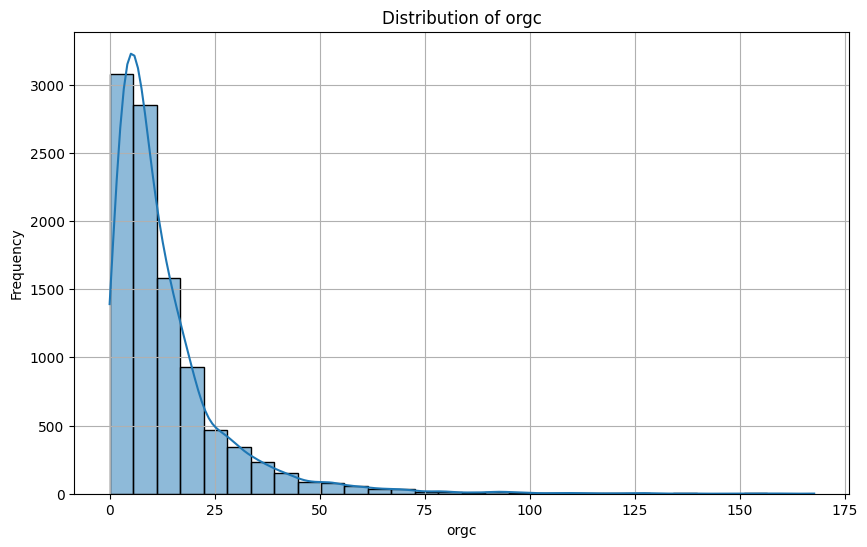

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['orgc'], bins=30, kde=True)
plt.title(f"Distribution of {'orgc'}")
plt.xlabel('orgc')
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [8]:
# %pip install plotly

In [9]:
import pandas as pd
import plotly.express as px

def bin_target(y, method='quantile'):
    """
    Bins the target into 5 categories using quantiles or equal-width bins.

    Args:
        y (pd.Series): Continuous target.
        method (str): 'quantile' or 'uniform'.

    Returns:
        pd.Series: Binned target with labels.
    """
    labels = ['very low', 'low', 'medium', 'high', 'very high']
    
    if method == 'quantile':
        b = pd.qcut(y, q=5)
        # Print bin intervals and counts
        print("Quantile Bins:")
        print(b.value_counts().sort_index())
        return pd.qcut(y, q=5, labels=labels)
    elif method == 'uniform':
        a = pd.cut(y, bins=5)
        # Print bin intervals and counts
        print("Uniform Bins:")
        print(a.value_counts().sort_index())
        return pd.cut(y, bins=5, labels=labels)
    else:
        raise ValueError("method must be 'quantile' or 'uniform'")

def plot_map_with_bins(df, title="Target Bins on Map", lat_col='latitude', lon_col='longitude', bin_col='target_bin'):
    """
    Plots a scatter map with color-coded bins.

    Args:
        df (pd.DataFrame): Data with latitude, longitude, and binned target.
        lat_col (str): Name of the latitude column.
        lon_col (str): Name of the longitude column.
        bin_col (str): Name of the binned target column.
    """
    fig = px.scatter_map(
        df,
        lat=lat_col,
        lon=lon_col,
        color=bin_col,
        color_discrete_sequence=px.colors.qualitative.Safe,
        zoom=3,
        height=600,
        map_style="carto-positron",
        title=title
    )
    fig.show()

In [10]:
q_bin = bin_target(df['orgc'], method='quantile')

q_df = df.copy()
q_df['target_bin'] = q_bin
plot_map_with_bins(q_df, title="Distribution of Organic Carbon (orgc) based on quantiles")

Quantile Bins:
orgc
(-0.001, 3.981]      2004
(3.981, 7.103]       2003
(7.103, 11.492]      2003
(11.492, 19.218]     2003
(19.218, 167.755]    2003
Name: count, dtype: int64


In [11]:
u_bin = bin_target(df['orgc'], method='uniform')
u_df = df.copy()
u_df['target_bin'] = u_bin
plot_map_with_bins(u_df, title="Distribution of Organic Carbon (orgc) based on uniform bins")

Uniform Bins:
orgc
(-0.168, 33.551]      9252
(33.551, 67.102]       643
(67.102, 100.653]       95
(100.653, 134.204]      19
(134.204, 167.755]       7
Name: count, dtype: int64


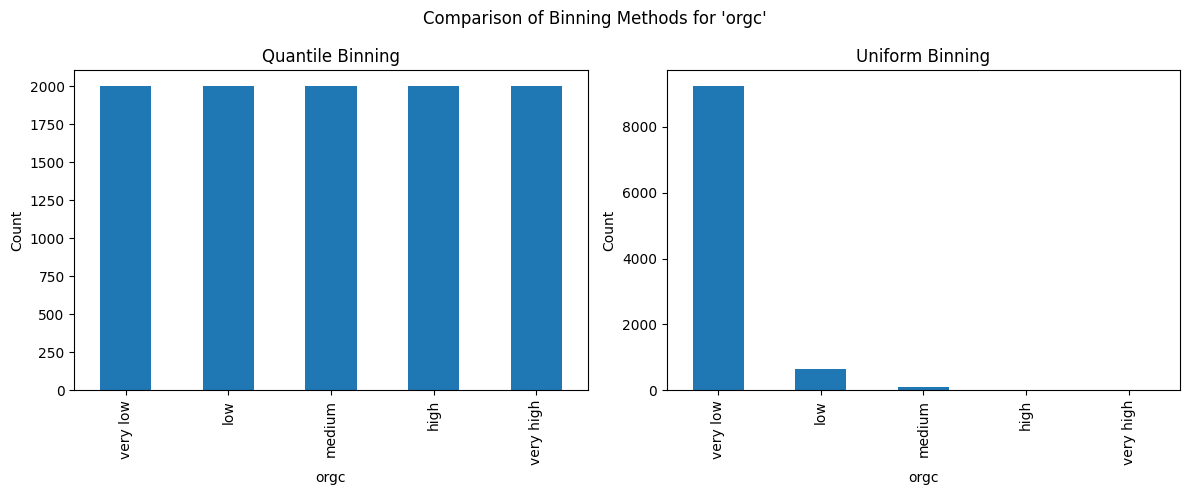

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of quantile bins
q_bin.value_counts().sort_index().plot(kind='bar', ax=axs[0], title="Quantile Binning")
axs[0].set_ylabel("Count")

# Histogram of uniform bins
u_bin.value_counts().sort_index().plot(kind='bar', ax=axs[1], title="Uniform Binning")
axs[1].set_ylabel("Count")

plt.suptitle("Comparison of Binning Methods for 'orgc'")
plt.tight_layout()
plt.show()


# Deep Learning model

Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8702 - loss: 1.2142 - val_accuracy: 0.9320 - val_loss: 0.3820
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9229 - loss: 0.3732 - val_accuracy: 0.9320 - val_loss: 0.3018
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9229 - loss: 0.3243 - val_accuracy: 0.9320 - val_loss: 0.2929
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9229 - loss: 0.3169 - val_accuracy: 0.9320 - val_loss: 0.2907
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9229 - loss: 0.3138 - val_accuracy: 0.9320 - val_loss: 0.2898
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9229 - loss: 0.3134 - val_accuracy: 0.9320 - val_loss: 0.2891
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9229 - loss: 0.3137 - val_accuracy: 0.9320 - val_loss: 0.2887
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9229 - loss: 0.3132 - val_accuracy: 0.

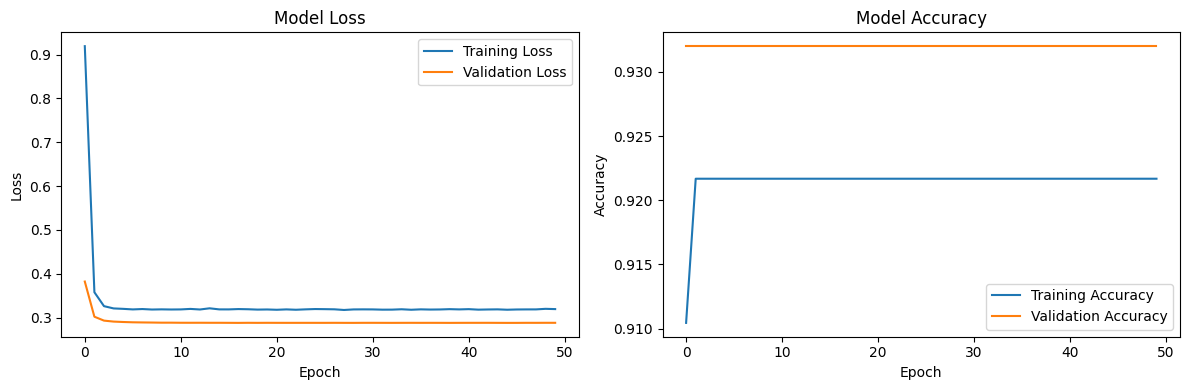


Test accuracy: 0.9237
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

    very low       0.92      1.00      0.96      1851
         low       0.00      0.00      0.00       129
      medium       0.00      0.00      0.00        19
        high       0.00      0.00      0.00         4
   very high       0.00      0.00      0.00         1

    accuracy                           0.92      2004
   macro avg       0.18      0.20      0.19      2004
weighted avg       0.85      0.92      0.89      2004



In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential # type:ignore
from tensorflow.keras.layers import Input, Dense, Dropout # type:ignore
from sklearn.metrics import classification_report
import tensorflow as tf
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Prepare features
X_numeric = df[numerical_features]
X_encoded = pd.get_dummies(df[categorical_features])
X = pd.concat([X_numeric, X_encoded], axis=1)

# Prepare target (using binned target)
y = pd.get_dummies(u_bin)

# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model configuration
INPUT_DIM = X_train.shape[1]
NUM_CLASSES = 5
BATCH_SIZE = 32
EPOCHS = 50

# Build model with consistent architecture
def build_model(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.1),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Create and train model
model = build_model(INPUT_DIM, NUM_CLASSES)
history = model.fit(
    X_train_scaled, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate model
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest accuracy: {test_accuracy:.4f}")

# Generate predictions and classification report
y_pred = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test.values, axis=1)

print("\nClassification Report:")
print(classification_report(
    y_test_classes, 
    y_pred_classes, 
    zero_division=0,
    target_names=['very low', 'low', 'medium', 'high', 'very high']
))

Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 352.4661 - mae: 12.8492 - val_loss: 265.9487 - val_mae: 10.2117
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 269.5645 - mae: 9.9489 - val_loss: 183.0879 - val_mae: 8.2038
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 197.9162 - mae: 8.6494 - val_loss: 169.3931 - val_mae: 8.9295
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 188.5534 - mae: 9.1802 - val_loss: 170.0819 - val_mae: 9.1772
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 187.9246 - mae: 9.2870 - val_loss: 170.2598 - val_mae: 9.2140
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 188.2762 - mae: 9.3307 - val_loss: 170.2711 - val_mae: 9.2162
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 188.3228 - mae: 9.3385 - val_loss: 170.2945 - val_mae: 9.2208
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 188.7816 - mae: 9.3567 - val_loss: 170.2294 - val_mae: 9.2079
Epoch 9/50
201/201 ━━━

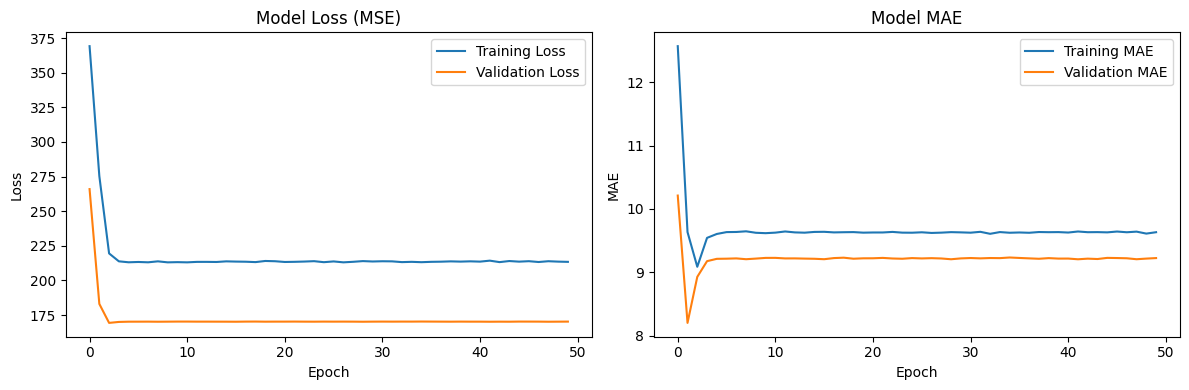

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Regression Metrics:
Mean Squared Error: 214.8036
Root Mean Squared Error: 14.6562
Mean Absolute Error: 9.5947
R² Score: -0.0003


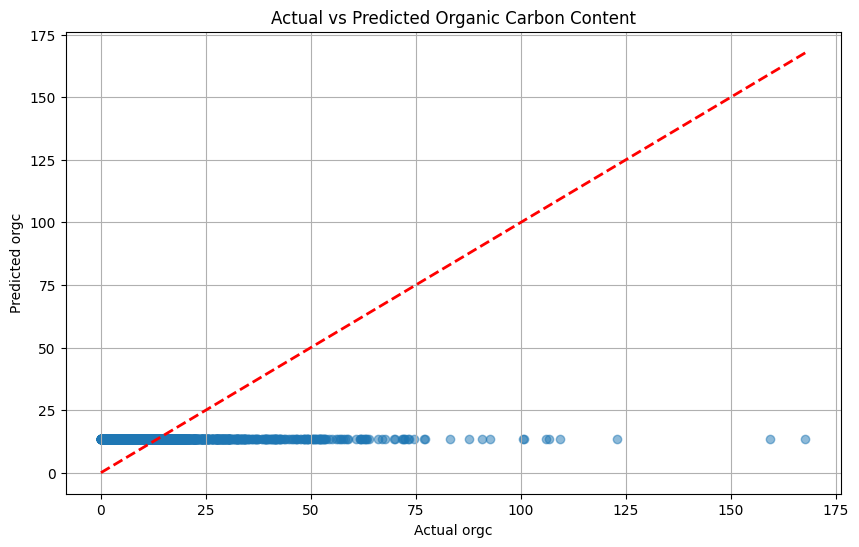

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential # type:ignore
from tensorflow.keras.layers import Input, Dense, Dropout # type:ignore
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Prepare features (using the same features as before)
X_numeric = df[numerical_features]
X_encoded = pd.get_dummies(df[categorical_features])
X = pd.concat([X_numeric, X_encoded], axis=1)

# Prepare target (using actual orgc values)
y = df['orgc']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model configuration
INPUT_DIM = X_train.shape[1]
BATCH_SIZE = 32
EPOCHS = 50

# Build regression model
def build_regression_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.1),
        Dense(1)  # Single output for regression
    ])
    
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

# Create and train model
regression_model = build_regression_model(INPUT_DIM)
history = regression_model.fit(
    X_train_scaled, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# Make predictions
y_pred = regression_model.predict(X_test_scaled)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nRegression Metrics:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual orgc')
plt.ylabel('Predicted orgc')
plt.title('Actual vs Predicted Organic Carbon Content')
plt.grid(True)
plt.show()